In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

filename = "FC26.csv"
df = pd.read_csv(filename)
df = df [["long_name","age","height_cm","overall", "potential", "player_positions", "value_eur", "release_clause_eur", "club_name","club_position","league_name", "league_level",
          "preferred_foot","weak_foot","skill_moves","international_reputation","work_rate","body_type"]]



C:\Users\Salman\AppData\Local\Temp\ipykernel_19972\1969524721.py:6: DtypeWarning: Columns (0: player_tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


In [28]:
df.drop_duplicates(inplace=True)
print(df.isnull().sum())
#df.dropna(how = 'all' ,inplace=True)

print(df[df['work_rate'].isna()])

#empty club, position, league means free agent
df.drop(columns=["work_rate"], inplace = True) # drop as it is empty for all
#for empty RC, add value + 15% val


long_name                       0
age                             0
height_cm                       0
overall                         0
potential                       0
player_positions                0
value_eur                       0
release_clause_eur           1434
club_name                      89
club_position                  89
league_name                    89
league_level                   89
preferred_foot                  0
weak_foot                       0
skill_moves                     0
international_reputation        0
work_rate                   18405
body_type                       0
dtype: int64
                                long_name  age  height_cm  overall  potential  \
0          Jude Victor William Bellingham   22        186       90         94   
1      Federico Santiago Valverde Dipetta   26        182       89         90   
2                   Joshua Walter Kimmich   30        177       89         89   
3            Achraf Hakimi Mouhأشرف حكيمي   26     

In [29]:
print(df[df.release_clause_eur.isna()].index)
for i in df[df.release_clause_eur.isnull()].index:
    df.loc[i, "release_clause_eur"] = df.loc[i, "value_eur"] *1.25

print(df.isnull().sum())
 


Index([   16,    55,    95,   111,   159,   171,   181,   221,   225,   245,
       ...
       17985, 17988, 18010, 18011, 18086, 18107, 18127, 18137, 18231, 18328],
      dtype='int64', length=1434)
long_name                    0
age                          0
height_cm                    0
overall                      0
potential                    0
player_positions             0
value_eur                    0
release_clause_eur           0
club_name                   89
club_position               89
league_name                 89
league_level                89
preferred_foot               0
weak_foot                    0
skill_moves                  0
international_reputation     0
body_type                    0
dtype: int64


In [30]:
#now fixing positions part, taking only 1 preferred position
c = 'player_positions' #variable to hold column name
print(df[c].head())
df[c] = df[c].str.split(",").str[0].str.strip()
print(df[c].head())


0        CAM, CM
1    CM, CDM, RB
2    CDM, RB, CM
3         RB, RM
4             CM
Name: player_positions, dtype: str
0    CAM
1     CM
2    CDM
3     RB
4     CM
Name: player_positions, dtype: object


In [31]:
print(df.info())
#now encode non numeric columns
#nonNumeric = ["long_name", "player_positions","preferred_foot","body_type"]
#DROP NAME
df.drop(columns = "long_name", inplace=True)
nonNumeric = df.select_dtypes(exclude = ["number"])

<class 'pandas.DataFrame'>
RangeIndex: 18405 entries, 0 to 18404
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   long_name                 18405 non-null  str    
 1   age                       18405 non-null  int64  
 2   height_cm                 18405 non-null  int64  
 3   overall                   18405 non-null  int64  
 4   potential                 18405 non-null  int64  
 5   player_positions          18405 non-null  object 
 6   value_eur                 18405 non-null  int64  
 7   release_clause_eur        18405 non-null  float64
 8   club_name                 18316 non-null  str    
 9   club_position             18316 non-null  str    
 10  league_name               18316 non-null  str    
 11  league_level              18316 non-null  float64
 12  preferred_foot            18405 non-null  str    
 13  weak_foot                 18405 non-null  int64  
 14  skill_moves      

In [32]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
for c in nonNumeric:
    df[c] = LabelEncoder().fit_transform(df[c])

#no column really requires scaling, lets still go for age
scaler = StandardScaler()
columns_to_scale = ['age']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [33]:
print(df.head())


        age  height_cm  overall  potential  player_positions  value_eur  \
0 -0.675102        186       90         94                 0  174500000   
1  0.162871        182       89         90                 3  120500000   
2  1.000844        177       89         89                 2   86000000   
3  0.162871        181       89         90                 8  111000000   
4  0.581857        175       87         87                 3   79500000   

   release_clause_eur  club_name  club_position  league_name  league_level  \
0         370800000.0        485              0           15           1.0   
1         256100000.0        485             17           15           1.0   
2         141900000.0        216             17            5           1.0   
3         213700000.0        442             14           22           1.0   
4         131199999.0        330             16           35           1.0   

   preferred_foot  weak_foot  skill_moves  international_reputation  body_type  

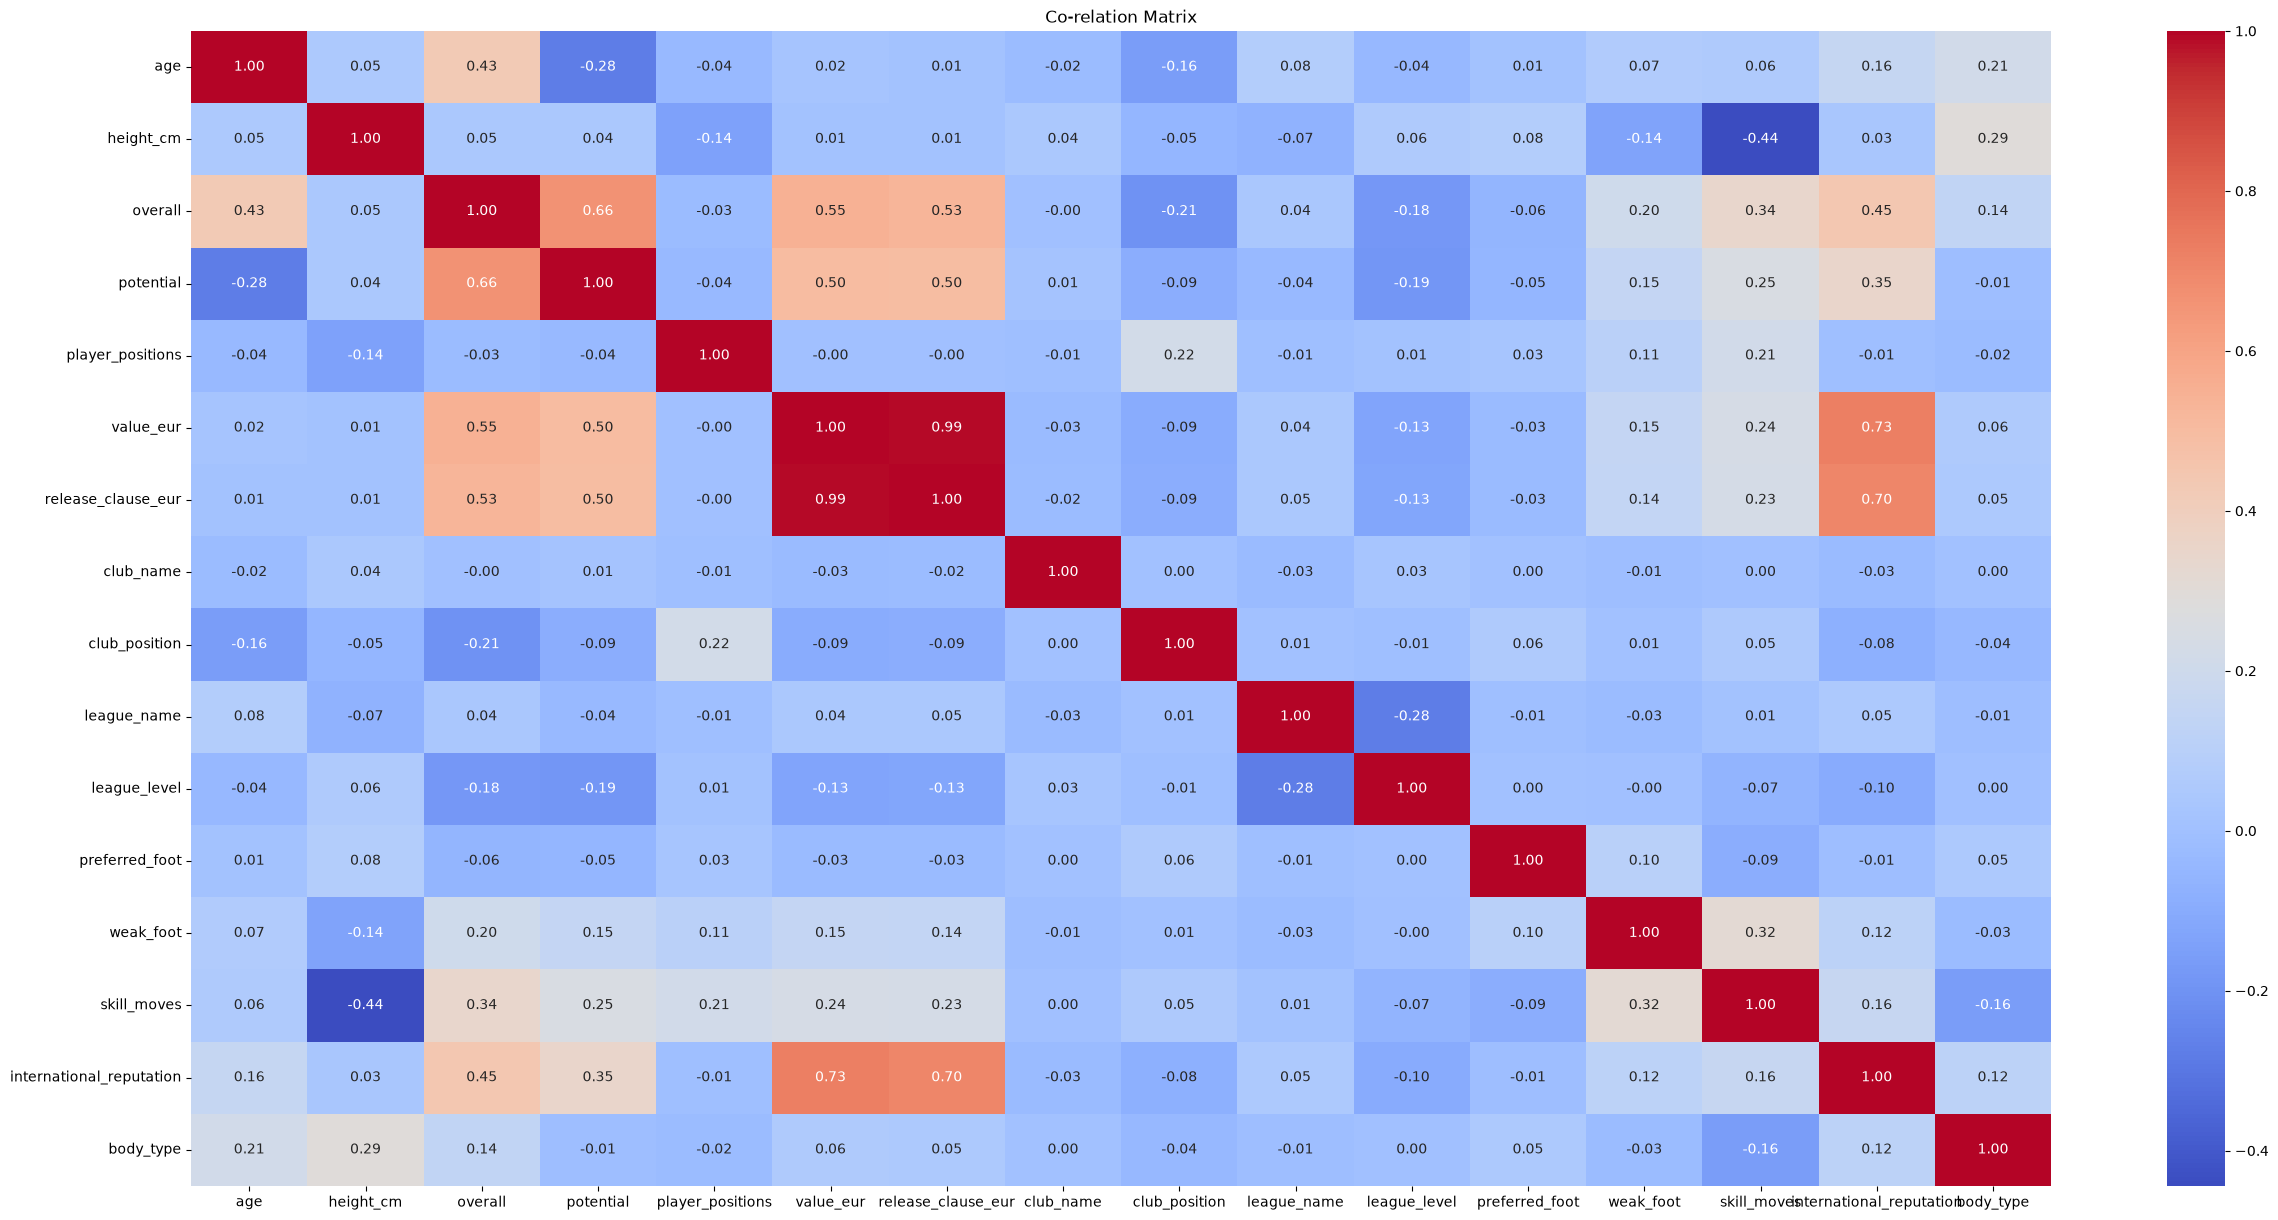

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.corr()
plt.figure(figsize=(30,15))
sns.heatmap(matrix, annot = True, cmap = 'coolwarm',fmt = '.2f')
plt.title("Co-relation Matrix")
plt.xticks(rotation = 360)
plt.show()

In [35]:
unnecessary_cols = ["age","height_cm","preferred_foot", "league_name", "player_positions"]
df_new = df.drop(columns = unnecessary_cols)



Text(0.5, 1.0, 'Before Outlier Removal - league_level')

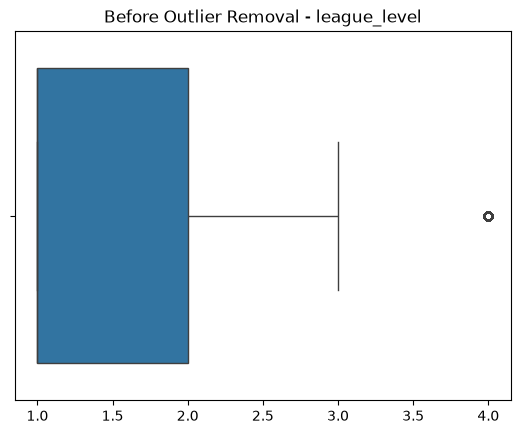

In [36]:
#in our dataset, outliers should not be removed as they are main points, so I am not removing for most columns, removing only for league_level

c = "league_level"
sns.boxplot(x = df_new[c])
plt.xlabel("")
plt.title(f"Before Outlier Removal - {c}")

In [37]:
Q1 = df_new[c].quantile(0.25)
Q3 = df_new[c].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5*IQR
higher_bound = Q3 + 1.5*IQR

df_new = df_new[(df_new[c] >= lower_bound) & (df_new[c] <=higher_bound)]


Text(0.5, 1.0, 'After Outlier Removal - league_level')

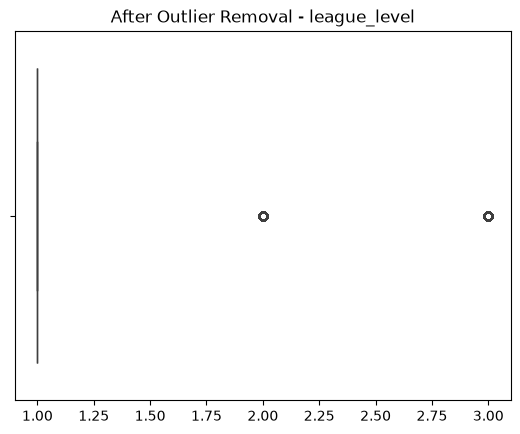

In [38]:
sns.boxplot(x = df_new[c])
plt.xlabel("")
plt.title(f"After Outlier Removal - {c}")

Original Value Counts:  value_eur
1200000     599
1100000     560
1600000     508
1300000     502
1000000     486
           ... 
84000000      1
83000000      1
70000000      1
61000000      1
97000000      1
Name: count, Length: 248, dtype: int64


<Axes: xlabel='value_eur', ylabel='Count'>

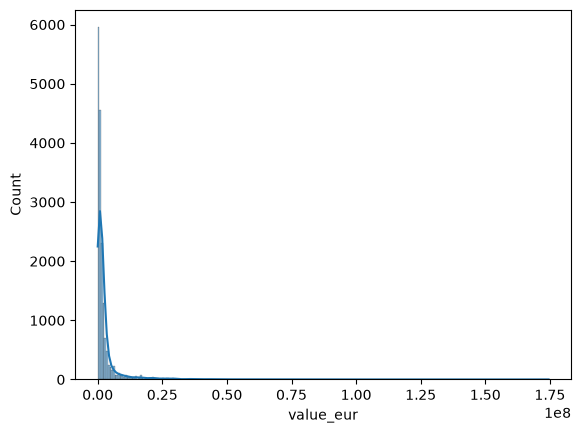

In [39]:
#oversampling,undersampling and combination
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
X = df_new.drop(columns = ["value_eur"])
y = df_new["value_eur"] #target column

##########below portion will not work as it is a continiuous variable
print("Original Value Counts: ",y.value_counts())
#balanced = SMOTETomek(random_state=42)
#X_resampled, y_resampled = balanced.fit_resample(X,y)
#print("Resampled Datasize: ", y_resampled.value_counts())


sns.histplot(df_new['value_eur'], kde=True)

<Axes: xlabel='log_value', ylabel='Count'>

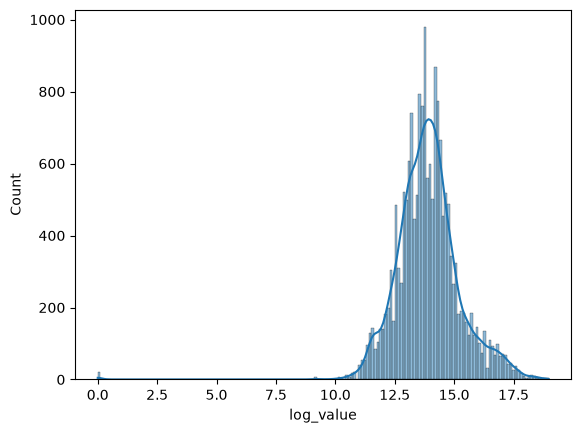

In [42]:
#my distribution looks like a gamma distribution 
#as my target column is not 0/1, I cannot simply apply undersampling, oversampling or combination.
#i am applying log trasnform beacuse most of the players have low market values with very few having huge values
#it will lessen the influence of extremely valuable players, and create a more stable relationship between features and target values.
#so the model may not spend too much effort fitting a few elite players and ignore ordinary players.
import numpy as np

df_new = pd.concat([X,y], axis = 1)
df_new['log_value'] = np.log1p(df_new['value_eur'])
df_new.to_csv("Updated.csv", index = False)
sns.histplot(df_new['log_value'], kde=True)